  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch    0 | loss 2.3051e+00
Epoch   10 | loss 3.7956e-01
Epoch   20 | loss 2.0757e-01
Epoch   30 | loss 1.4073e-01
Epoch   40 | loss 1.1279e-01
Epoch   50 | loss 9.8375e-02
Epoch   60 | loss 9.1850e-02
Epoch   70 | loss 8.5295e-02
Epoch   80 | loss 8.0922e-02
Epoch   90 | loss 7.7546e-02
Epoch  100 | loss 7.7525e-02
Epoch  110 | loss 7.3818e-02
Epoch  120 | loss 7.3811e-02
Epoch  130 | loss 7.1537e-02
Epoch  140 | loss 6.9628e-02
Epoch  150 | loss 6.9562e-02
Epoch  160 | loss 6.8096e-02
Epoch  170 | loss 6.6669e-02
Epoch  180 | loss 6.8408e-02
Epoch  190 | loss 6.5645e-02
Epoch  200 | loss 6.4577e-02
Epoch  210 | loss 6.5664e-02
Epoch  220 | loss 6.3890e-02
Epoch  230 | loss 6.1943e-02
Epoch  240 | loss 7.1421e-02
Epoch  250 | loss 6.5137e-02
Epoch  260 | loss 6.1600e-02
Epoch  270 | loss 6.0214e-02
Epoch  280 | loss 6.6425e-02
Epoch  290 | loss 6.4159e-02
Epoch  300 | loss 6.0863e-02
Epoch  310 | loss 5.9135e-02
Epoch  320 | loss 5.8237e-02
Epoch  330 | loss 5.7881e-02
Epoch  340 | l

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch    0 | loss 6.7651e-01
Epoch   10 | loss 2.1694e-01
Epoch   20 | loss 1.5878e-01
Epoch   30 | loss 1.2491e-01
Epoch   40 | loss 9.3789e-02
Epoch   50 | loss 7.7448e-02
Epoch   60 | loss 6.5486e-02
Epoch   70 | loss 6.0653e-02
Epoch   80 | loss 5.8614e-02
Epoch   90 | loss 5.7359e-02
Epoch  100 | loss 5.6528e-02
Epoch  110 | loss 5.6114e-02
Epoch  120 | loss 5.5582e-02
Epoch  130 | loss 5.5080e-02
Epoch  140 | loss 5.4741e-02
Epoch  150 | loss 5.4463e-02
Epoch  160 | loss 5.4236e-02
Epoch  170 | loss 5.4051e-02
Epoch  180 | loss 5.3832e-02
Epoch  190 | loss 5.4444e-02
Epoch  200 | loss 5.3581e-02
Epoch  210 | loss 5.3348e-02
Epoch  220 | loss 5.3137e-02
Epoch  230 | loss 5.2971e-02
Epoch  240 | loss 5.2849e-02
Epoch  250 | loss 5.2783e-02
Epoch  260 | loss 5.2658e-02
Epoch  270 | loss 5.2491e-02
Epoch  280 | loss 5.2380e-02
Epoch  290 | loss 5.2555e-02
Epoch  300 | loss 5.2373e-02
Epoch  310 | loss 5.2217e-02
Epoch  320 | loss 5.2074e-02
Epoch  330 | loss 5.1980e-02
Epoch  340 | l

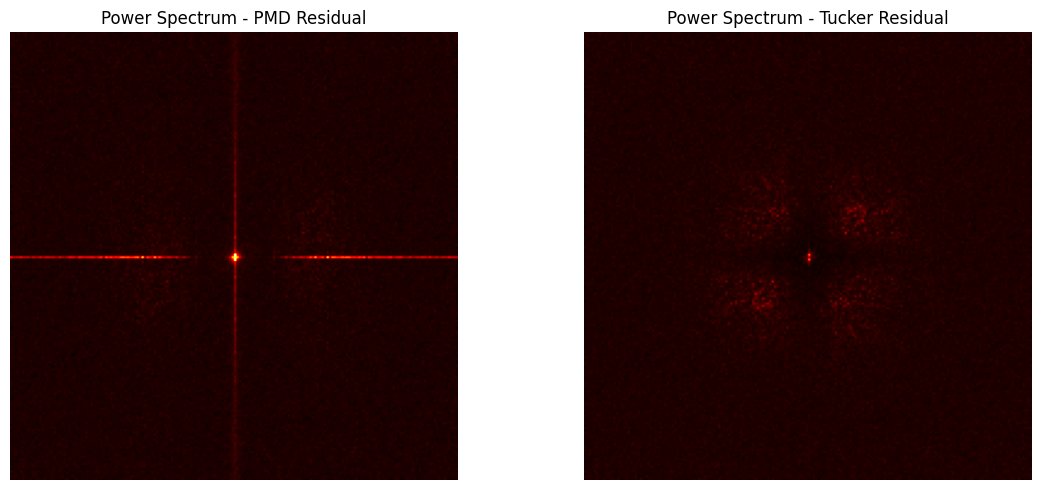

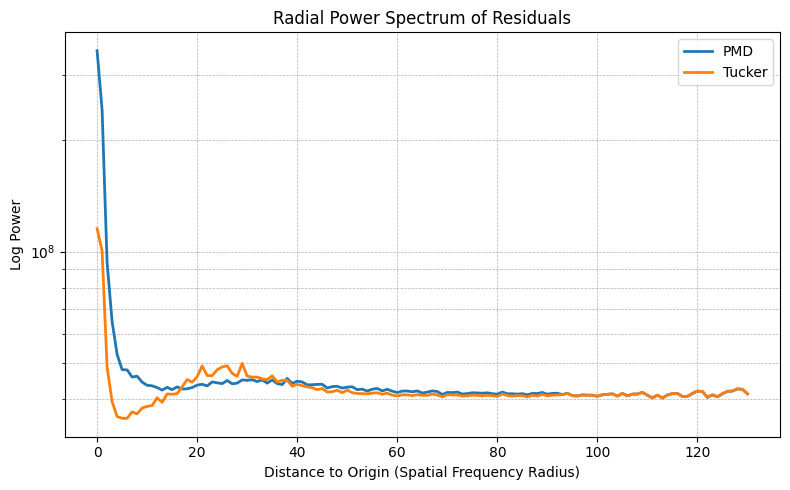

In [1]:
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import torch
from models.skip1d import*
from tqdm.notebook import tqdm
import time
from matplotlib.patches import Rectangle
from numpy.fft import fft2, fftshift
from scipy.stats import pearsonr

def PMD(video_tensor_flattened, rank_HW, rank_T, H, W, T, epochs, learning_rate):

    hw_inp = get_1d_posencode_inp(H*W, rank_HW//2)
    t_inp = get_1d_posencode_inp(T, rank_T//2)

    # Define parameters for skip1d
    skip_n33d = 128  # Number of channels in the downsampling path
    skip_n33u = 128  # Number of channels in the upsampling path
    skip_n11 = 4   # Number of channels in the skip connection
    num_scales = 5  # Number of scales in the skip connection
    upsample_mode = 'linear'  # Upsampling mode
    downsample_mode = 'stride'  # Downsampling mode
    pad = 'reflection'  # Padding mode
    act_fun = 'LeakyReLU'  # Activation function
    filter_size_up=3
    filter_size_down=3 
    filter_size_skip=1


    hw_net = skip1d(
        rank_HW,                       # Dimensionality of positional encoding (e.g., 32)
        rank_HW,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    t_net = skip1d(
        rank_T,                       # Dimensionality of positional encoding (e.g., 32)
        rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    # Switch to trairning mode
    hw_net.train()
    t_net.train()

    net_params = list(hw_net.parameters()) + list(t_net.parameters())
    inp_params = [hw_inp] + [t_inp]
    params = net_params + inp_params

    criterion_l1 = L2Norm()
        
    loss_array = np.zeros(epochs)
    mse_array = np.zeros(epochs)    
    time_array = np.zeros(epochs)

    optimizer = torch.optim.Adam(lr=learning_rate, params=params)
        
    # Create a learning scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

    u_inp_per = hw_inp.detach().clone()
    v_inp_per = t_inp.detach().clone()

    best_loss = float('inf')
    best_epoch = 0
    tic = time.time()

    tbar = tqdm(range(epochs))

    frame_idx = 100  # Example frame index to visualize
    x, y = 65, 50      # top-left corner (column, row)
    width, height = 50, 52

    def plot_frame_with_rectangle(frame, x, y, width, height):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(frame, cmap='hot')
        
        # Add rectangle patch
        rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='b', facecolor='none')
        ax.add_patch(rect)

        ax.set_title(f"Rectangle at ({x}, {y}), w={width}, h={height}")
        plt.grid(False)
        plt.axis('off')
        plt.show()

    for idx in tbar:
        A_hw = hw_net(hw_inp).squeeze(0).permute(1, 0)  # [H, 32]
        A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

        recon = torch.matmul(A_hw, A_t.T)

        loss = criterion_l1(video_tensor_flattened - recon)

        # Track metrics
        loss_array[idx] = loss.item()
        time_array[idx] = time.time() - tic

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_epoch = idx
            best_reconstruction = recon.detach().clone()

        # Backprop
        optimizer.zero_grad()
        torch.autograd.set_detect_anomaly(True)
        loss.backward()
        optimizer.step()
        scheduler.step()  # optional

        # Optionally visualize or print
        if idx % 10 == 0:
            print(f'Epoch {idx:4d} | loss {loss.item():.4e}')
        
    return {
        'best_loss': best_loss,
        'best_epoch': best_epoch,
        'best_reconstruction': best_reconstruction.reshape(H, W, T).permute(2, 0, 1),
    }


def Tucker(video_tensor, rank_H, rank_W, rank_T, H, W, T, epochs, learning_rate):

    h_inp = get_1d_posencode_inp(H, rank_H//2)
    w_inp = get_1d_posencode_inp(W, rank_W//2)
    t_inp = get_1d_posencode_inp(T, rank_T//2)

    # Define parameters for skip1d
    skip_n33d = 128  # Number of channels in the downsampling path
    skip_n33u = 128  # Number of channels in the upsampling path
    skip_n11 = 4   # Number of channels in the skip connection
    num_scales = 5  # Number of scales in the skip connection
    upsample_mode = 'linear'  # Upsampling mode
    downsample_mode = 'stride'  # Downsampling mode
    pad = 'reflection'  # Padding mode
    act_fun = 'LeakyReLU'  # Activation function
    filter_size_up=3
    filter_size_down=3 
    filter_size_skip=1


    h_net = skip1d(
        rank_H,                       # Dimensionality of positional encoding (e.g., 32)
        rank_H,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    w_net = skip1d(
        rank_W,                       # Dimensionality of positional encoding (e.g., 32)
        rank_W,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    t_net = skip1d(
        rank_T,                       # Dimensionality of positional encoding (e.g., 32)
        rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    # Switch to trairning mode
    h_net.train()
    w_net.train()
    t_net.train()

    net_params = list(h_net.parameters()) + list(w_net.parameters()) + list(t_net.parameters())
    inp_params = [h_inp] + [w_inp] + [t_inp]
    params = net_params + inp_params

    core = torch.nn.Parameter(torch.ones((rank_T, rank_H, rank_W), dtype=torch.float32) /
        (rank_T * rank_H * rank_W) ** 0.5)
    params += [core]

    criterion_l1 = L2Norm()
        
    loss_array = np.zeros(epochs)
    mse_array = np.zeros(epochs)    
    time_array = np.zeros(epochs)

    optimizer = torch.optim.Adam(lr=learning_rate, params=params)
        
    # Create a learning scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

    u_inp_per = h_inp.detach().clone()
    v_inp_per = w_inp.detach().clone()
    w_inp_per = t_inp.detach().clone()

    best_loss = float('inf')
    best_epoch = 0
    tic = time.time()

    tbar = tqdm(range(epochs))

    for idx in tbar:
        A_h = h_net(h_inp).squeeze(0).permute(1, 0)  # [H, 32]
        A_w = w_net(w_inp).squeeze(0).permute(1, 0)  # [W, 32]
        A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

        # recon = torch.einsum('tr,hr,wr,rxy->thw', A_t, A_h, A_w, core)  # (T,H,W)

        # 1. Multiply along temporal mode (mode-0)
        out = torch.einsum('tr, rhw -> thw', A_t, core)      # [T, R_H, R_W]

        # 2. Multiply along spatial height (mode-1)
        out = torch.einsum('trw, hr -> t w h', out, A_h)     # [T, H, R_W]

        # 3. Multiply along spatial width (mode-2)
        recon = torch.einsum('trh, wr -> thw', out, A_w)     # [T, H, W]

        loss = criterion_l1(video_tensor - recon)

        # Track metrics
        loss_array[idx] = loss.item()
        time_array[idx] = time.time() - tic

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_epoch = idx
            best_reconstruction = recon.detach().clone()

        # Backprop
        optimizer.zero_grad()
        torch.autograd.set_detect_anomaly(True)
        loss.backward()
        optimizer.step()
        scheduler.step()  # optional

        # Optionally visualize or print
        if idx % 10 == 0:
            print(f'Epoch {idx:4d} | loss {loss.item():.4e}')

    return {
        'best_loss': best_loss,
        'best_epoch': best_epoch,
        'best_reconstruction': best_reconstruction,
    }


def compute_avg_power_spectrum(video_scaled, recon_scaled):
    """
    Computes the average squared norm of the Fourier transform of residuals
    across all frames in a video.
    """
    T = video_scaled.shape[0]
    power_spectra = []

    for t in range(T):
        residual = (video_scaled[t] - recon_scaled[t]).cpu().numpy()
        f = fft2(residual)
        fshift = fftshift(f)
        power = np.abs(fshift) ** 2
        power_spectra.append(power)

    avg_power = np.mean(power_spectra, axis=0)
    return avg_power

def plot_power_spectra_comparison(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    """
    Computes and plots the power spectra of residuals from PMD and Tucker reconstructions.
    """
    avg_ps_pmd = compute_avg_power_spectrum(video_scaled, recon_pmd_scaled)
    avg_ps_tucker = compute_avg_power_spectrum(video_scaled, recon_tucker_scaled)

    vmax = max(avg_ps_pmd.max(), avg_ps_tucker.max())

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(avg_ps_pmd, cmap='hot', vmax=vmax)
    axs[0].set_title("Power Spectrum - PMD Residual")
    axs[0].axis('off')

    axs[1].imshow(avg_ps_tucker, cmap='hot', vmax=vmax)
    axs[1].set_title("Power Spectrum - Tucker Residual")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

def compute_avg_power_spectrum(video_scaled, recon_scaled):
    T = video_scaled.shape[0]
    power_spectra = []

    for t in range(T):
        residual = (video_scaled[t] - recon_scaled[t]).cpu().numpy()
        f = fft2(residual)
        fshift = fftshift(f)
        power = np.abs(fshift) ** 2
        power_spectra.append(power)

    avg_power = np.mean(power_spectra, axis=0)
    return avg_power

def radial_profile(power_spectrum):
    """
    Computes the radial average of a 2D power spectrum.
    """
    h, w = power_spectrum.shape
    y, x = np.indices((h, w))
    center = (h // 2, w // 2)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(np.int32)

    # Compute mean power at each radial frequency
    tbin = np.bincount(r.ravel(), power_spectrum.ravel())
    nr = np.bincount(r.ravel())
    radial_profile = tbin / np.maximum(nr, 1)

    return radial_profile

def plot_radial_power_comparison(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    """
    Computes and plots log radial power spectrum for PMD and Tucker residuals.
    """
    avg_ps_pmd = compute_avg_power_spectrum(video_scaled, recon_pmd_scaled)
    avg_ps_tucker = compute_avg_power_spectrum(video_scaled, recon_tucker_scaled)

    radial_pmd = radial_profile(avg_ps_pmd)
    radial_tucker = radial_profile(avg_ps_tucker)

    r = np.arange(len(radial_pmd))

    plt.figure(figsize=(8, 5))
    plt.semilogy(r, radial_pmd + 1e-8, label='PMD', linewidth=2)
    plt.semilogy(r, radial_tucker + 1e-8, label='Tucker', linewidth=2)
    plt.xlabel("Distance to Origin (Spatial Frequency Radius)")
    plt.ylabel("Log Power")
    plt.title("Radial Power Spectrum of Residuals")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

device = 'cpu'
torch.set_default_dtype(torch.float32)

base_path = "E:\\Voltron2_part1\\Voltron_Cell1"

tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)

tif_path = os.path.join(base_path, tif_file)

# Read TIFF file
vol_data = tifffile.imread(tif_path)  # shape: (T, H, W) or (H, W)

# Normalize the full video globally
full_video = torch.tensor(vol_data.astype(np.float32), dtype=torch.float32)
mean_val = full_video.mean()
std_val = full_video.std()

full_video_norm = (full_video - mean_val) / std_val

# Subsample 200 frames
video_tensor = full_video_norm[800:1000]

H, W, T = video_tensor.shape[1], video_tensor.shape[2], video_tensor.shape[0]

video_tensor_flattened = video_tensor.permute(1, 2, 0).reshape(-1, T)  # shape: (H*W, T)

video_tensor_scaled = video_tensor * std_val + mean_val  # Rescale to original values


rank_HW_pmd = 48
rank_T_pmd = 48
epochs_pmd = 1000
learning_rate_pmd = 1e-4

rank_H = 48
rank_W = 48
rank_T = 48
epochs = 1000
learning_rate = 1e-4

# Run PMD
pmd_results = PMD(video_tensor_flattened, rank_HW_pmd, rank_T_pmd, H, W, T, epochs_pmd, learning_rate_pmd)

# Run Tucker
tucker_results = Tucker(video_tensor, rank_H, rank_W, rank_T, H, W, T, epochs, learning_rate)

pmd_results['best_reconstruction'] = pmd_results['best_reconstruction']* std_val + mean_val
tucker_results['best_reconstruction'] = tucker_results['best_reconstruction']* std_val + mean_val

# Plot power spectra comparison
plot_power_spectra_comparison(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

# Plot radial power comparison
plot_radial_power_comparison(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

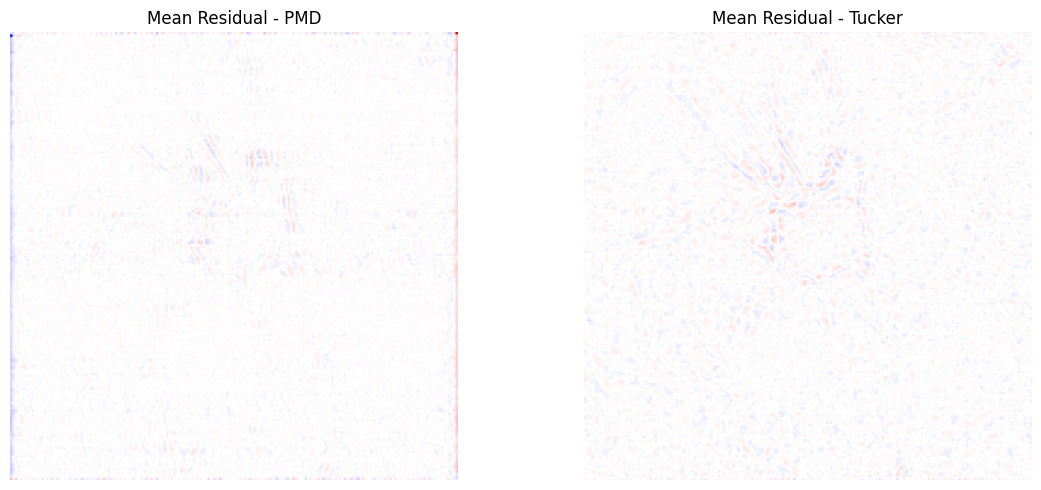

In [2]:
def compute_average_residual(video_scaled, recon_scaled):
    """
    Computes the temporal mean of residuals (video - reconstruction).
    
    Args:
        video_scaled (Tensor): shape (T, H, W)
        recon_scaled (Tensor): shape (T, H, W)
    
    Returns:
        avg_residual (Tensor): shape (H, W)
    """
    residual = video_scaled - recon_scaled  # shape: (T, H, W)
    avg_residual = residual.mean(dim=0)     # shape: (H, W)
    return avg_residual

def plot_average_residuals(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    """
    Plots the average residuals for PMD and Tucker reconstructions.
    """
    avg_residual_pmd = compute_average_residual(video_scaled, recon_pmd_scaled).cpu().numpy()
    avg_residual_tucker = compute_average_residual(video_scaled, recon_tucker_scaled).cpu().numpy()

    vmax = max(abs(avg_residual_pmd).max(), abs(avg_residual_tucker).max())

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(avg_residual_pmd, cmap='bwr', vmin=-vmax, vmax=vmax)
    axs[0].set_title("Mean Residual - PMD")
    axs[0].axis('off')

    axs[1].imshow(avg_residual_tucker, cmap='bwr', vmin=-vmax, vmax=vmax)
    axs[1].set_title("Mean Residual - Tucker")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

plot_average_residuals(video_tensor_scaled, 
                       pmd_results['best_reconstruction'], 
                       tucker_results['best_reconstruction'])